**A Sentiment Analysis of the 10 Most Discussed Characters in the Naruto Franchise: A Comparative Study of YouTube Fan Interactions across Naruto, Shippuden, and Boruto.**

CELL 1: Setup & Libraries

In [34]:
# ========================== CELL 1: SETUP ==========================
!pip install -q google-api-python-client vaderSentiment pandas matplotlib seaborn

from google.colab import userdata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter
from googleapiclient.discovery import build
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime

warnings.filterwarnings('ignore')

# ==================== UPDATED SECRET NAME ====================
API_KEY = userdata.get('NARUTO_YOUTUBE_ANALYSIS_KEY')

if not API_KEY:
    raise ValueError("❌ Secret 'NARUTO_YOUTUBE_ANALYSIS_KEY' not found! Please add it in Colab Secrets with this exact name.")

youtube = build('youtube', 'v3', developerKey=API_KEY)
print("✅ YouTube API Connected Successfully!")
print(f"📅 Run Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("🔑 Using Secret Name: NARUTO_YOUTUBE_ANALYSIS_KEY")

✅ YouTube API Connected Successfully!
📅 Run Time: 2026-06-05 21:13:58
🔑 Using Secret Name: NARUTO_YOUTUBE_ANALYSIS_KEY


CELL 2: Character List (with aliases)

In [36]:
# ========================== CELL 2: CHARACTERS ==========================
NARUTO_CHARACTERS = {
    "Naruto": ["naruto", "naruto uzumaki"],
    "Sasuke": ["sasuke", "sasuke uchiha"],
    "Sakura": ["sakura", "sakura haruno"],
    "Kakashi": ["kakashi", "kakashi hatake"],
    "Itachi": ["itachi", "itachi uchiha"],
    "Madara": ["madara", "madara uchiha"],
    "Obito": ["obito", "obito uchiha", "tobi"],
    "Hinata": ["hinata", "hinata hyuga"],
    "Minato": ["minato", "minato namikaze", "fourth hokage"],
    "Jiraiya": ["jiraiya"],
    "Gaara": ["gaara"],
    "Shikamaru": ["shikamaru"],
    "Rock Lee": ["rock lee", "rocklee"],
    "Pain": ["pain", "nagato"],
    "Boruto": ["boruto", "boruto uzumaki"],
    "Sarada": ["sarada", "sarada uchiha"],
    "Kawaki": ["kawaki"],
    "Mitsuki": ["mitsuki"],
    "Himawari": ["himawari"],
    "Isshiki": ["isshiki", "isshiki otsutsuki"]
}

print(f"✅ Successfully loaded {len(NARUTO_CHARACTERS)} characters with name variations")

✅ Successfully loaded 20 characters with name variations


CELL 3: Video Collection

In [37]:
# ========================== CELL 3: VIDEO COLLECTION ==========================
def search_videos(query, max_results=6):
    try:
        request = youtube.search().list(
            q=query, part="snippet", type="video", maxResults=max_results,
            relevanceLanguage="en", order="relevance"
        )
        response = request.execute()
        return [{"video_id": item["id"]["videoId"], "title": item["snippet"]["title"]}
                for item in response.get("items", [])]
    except Exception as e:
        print(f"⚠️ Search error: {e}")
        return []

queries = [
    "Naruto best characters all time",
    "Naruto Shippuden best moments",
    "Boruto Next Generations best characters",
    "Itachi best moments reaction",
    "Naruto vs Sasuke final fight reaction",
    "Boruto vs Kawaki best moments",
    "Top 10 strongest Naruto characters 2025"
]

all_videos = []
print("🔍 Searching YouTube videos...")

for query in queries:
    videos = search_videos(query)
    all_videos.extend(videos)
    print(f"   Found {len(videos)} videos for: {query}")

# High-quality hardcoded video IDs (popular Naruto content)
hardcoded_ids = ["2CMocsxSXv8", "YC94ERD3tNo", "NcVZilkktKk", "_fq1fnKHjik", "440XU_OdXVI", "kJ5p9fJq7z0"]
for vid in hardcoded_ids:
    all_videos.append({"video_id": vid, "title": "Popular Naruto Analysis Video"})

videos_df = pd.DataFrame(all_videos).drop_duplicates(subset="video_id").reset_index(drop=True)
print(f"\n📊 Total unique videos selected: {len(videos_df)}")

🔍 Searching YouTube videos...
   Found 6 videos for: Naruto best characters all time
   Found 6 videos for: Naruto Shippuden best moments
   Found 6 videos for: Boruto Next Generations best characters
   Found 6 videos for: Itachi best moments reaction
   Found 6 videos for: Naruto vs Sasuke final fight reaction
   Found 6 videos for: Boruto vs Kawaki best moments
   Found 6 videos for: Top 10 strongest Naruto characters 2025

📊 Total unique videos selected: 46


CELL 4: Collect Comments

In [38]:
# ========================== CELL 4: COLLECT COMMENTS ==========================
def get_comments(video_id, max_comments=90):
    comments = []
    try:
        request = youtube.commentThreads().list(
            part="snippet", videoId=video_id, maxResults=100,
            textFormat="plainText", order="relevance"
        )
        while request and len(comments) < max_comments:
            response = request.execute()
            for item in response.get("items", []):
                comments.append(item["snippet"]["topLevelComment"]["snippet"]["textDisplay"])
            request = youtube.commentThreads().list_next(request, response)
    except:
        pass
    return comments

all_comments = []
print("💬 Collecting comments from videos (this may take 30–90 seconds)...")

for _, row in videos_df.iterrows():
    print(f"   → {row['title'][:55]}...")
    comments = get_comments(row["video_id"], 90)
    all_comments.extend(comments)

comments_df = pd.DataFrame({"raw_comment": all_comments})
print(f"\n✅ Total comments collected: {len(comments_df)}")

💬 Collecting comments from videos (this may take 30–90 seconds)...
   → Top 10 Strongest Naruto Characters ⚡⚡...
   → Ranking Naruto Characters Based On Aura...
   → The Top 9 Strongest In Naruto?...
   → Top 10 Strongest Characters in Naruto...
   → Top 10 Naruto Most Powerful Character 👿 #shorts #youtub...
   → 15 Most Handsome Naruto Characters...
   → Top 30 Iconic Naruto Moments...
   → Top 10 Fights of Naruto Shippuden...
   → Top 4 AURA Moments In Naruto😎...
   → Top 10 Naruto Shippuuden Fights...
   → Naruto Shippuden funny moments compilation #2...
   → naruto shippuden funny moments dubbed part 1.wmv...
   → Top 7 strongest characters in boruto after the timeskip...
   → The Strongest Character in Boruto...
   → Top 20                                                 ...
   → Top 10 MOST POWERFUL CHARACTERS in Boruto/Two Blue Vort...
   → Top 10 Boruto Strongest Characters 🔥🔥...
   → Top 10 Strongest Characters in Boruto Two Blue Vortex...
   → Itachi defeats Orochimaru with j

CELL 5: Find Top 10 Most Famous Characters

In [39]:
# ========================== CELL 5: TOP 10 CHARACTERS ==========================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

comments_df["clean_comment"] = comments_df["raw_comment"].apply(clean_text)
comments_df = comments_df[comments_df["clean_comment"].str.len() > 10].reset_index(drop=True)

mention_counts = Counter()
for comment in comments_df["clean_comment"]:
    for char, aliases in NARUTO_CHARACTERS.items():
        if any(re.search(r'\b' + re.escape(alias) + r'\b', comment) for alias in aliases):
            mention_counts[char] += 1

top10_df = pd.DataFrame(mention_counts.items(), columns=["Character", "Mentions"])\
             .sort_values("Mentions", ascending=False).head(10).reset_index(drop=True)

print("🏆 TOP 10 MOST FAMOUS CHARACTERS (by YouTube mention count)")
print(top10_df)

🏆 TOP 10 MOST FAMOUS CHARACTERS (by YouTube mention count)
  Character  Mentions
0    Naruto       590
1    Sasuke       338
2    Boruto       263
3    Itachi       237
4   Kakashi       167
5    Madara       117
6    Kawaki        92
7    Sakura        79
8     Obito        79
9      Pain        61


CELL 6: Sentiment Analysis

In [40]:
# ========================== CELL 6: SENTIMENT ANALYSIS (Improved) ==========================
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

results = []
print("🔄 Starting Sentiment Analysis on Top 10 Characters...\n")

for idx, row in top10_df.iterrows():
    char = row["Character"]
    mentions = int(row["Mentions"])
    aliases = NARUTO_CHARACTERS.get(char, [char.lower()])

    # Create regex pattern for all name variations
    pattern = r'\b(' + '|'.join(re.escape(alias) for alias in aliases) + r')\b'

    # Filter comments mentioning this character
    char_comments = comments_df[comments_df["clean_comment"].str.contains(pattern, regex=True, case=False)]
    total_comments = len(char_comments)

    print(f"Analyzing {char:12} → {total_comments:4} comments found")

    if total_comments == 0:
        print(f"   ⚠️ No comments found for {char}\n")
        continue

    # Calculate sentiment scores
    scores = [analyzer.polarity_scores(text)["compound"] for text in char_comments["clean_comment"]]
    avg_score = sum(scores) / len(scores)

    positive = sum(1 for s in scores if s >= 0.05)
    negative = sum(1 for s in scores if s <= -0.05)
    neutral = len(scores) - positive - negative

    pos_pct = (positive / total_comments) * 100
    neg_pct = (negative / total_comments) * 100
    neu_pct = (neutral / total_comments) * 100

    results.append({
        "Character": char,
        "Mentions": mentions,
        "Positive": positive,
        "Negative": negative,
        "Neutral": neutral,
        "Positive_%": round(pos_pct, 1),
        "Negative_%": round(neg_pct, 1),
        "Avg_Sentiment": round(avg_score, 3),
        "Overall": "Strongly Positive" if avg_score >= 0.35 else
                   "Positive" if avg_score >= 0.05 else
                   "Negative" if avg_score <= -0.05 else "Neutral/Mixed"
    })

final_df = pd.DataFrame(results).sort_values("Mentions", ascending=False).reset_index(drop=True)

print("\n🎯 FINAL SENTIMENT ANALYSIS RESULTS")
print("="*80)
print(final_df)
print("="*80)
print(f"\nTotal characters analyzed: {len(final_df)}")

🔄 Starting Sentiment Analysis on Top 10 Characters...

Analyzing Naruto       →  590 comments found
Analyzing Sasuke       →  338 comments found
Analyzing Boruto       →  263 comments found
Analyzing Itachi       →  237 comments found
Analyzing Kakashi      →  167 comments found
Analyzing Madara       →  117 comments found
Analyzing Kawaki       →   92 comments found
Analyzing Sakura       →   79 comments found
Analyzing Obito        →   79 comments found
Analyzing Pain         →   61 comments found

🎯 FINAL SENTIMENT ANALYSIS RESULTS
  Character  Mentions  Positive  Negative  Neutral  Positive_%  Negative_%  \
0    Naruto       590       267       166      157        45.3        28.1   
1    Sasuke       338       153       109       76        45.3        32.2   
2    Boruto       263       110        69       84        41.8        26.2   
3    Itachi       237       108        59       70        45.6        24.9   
4   Kakashi       167        51        37       79        30.5       

CELL 7: Visualizations

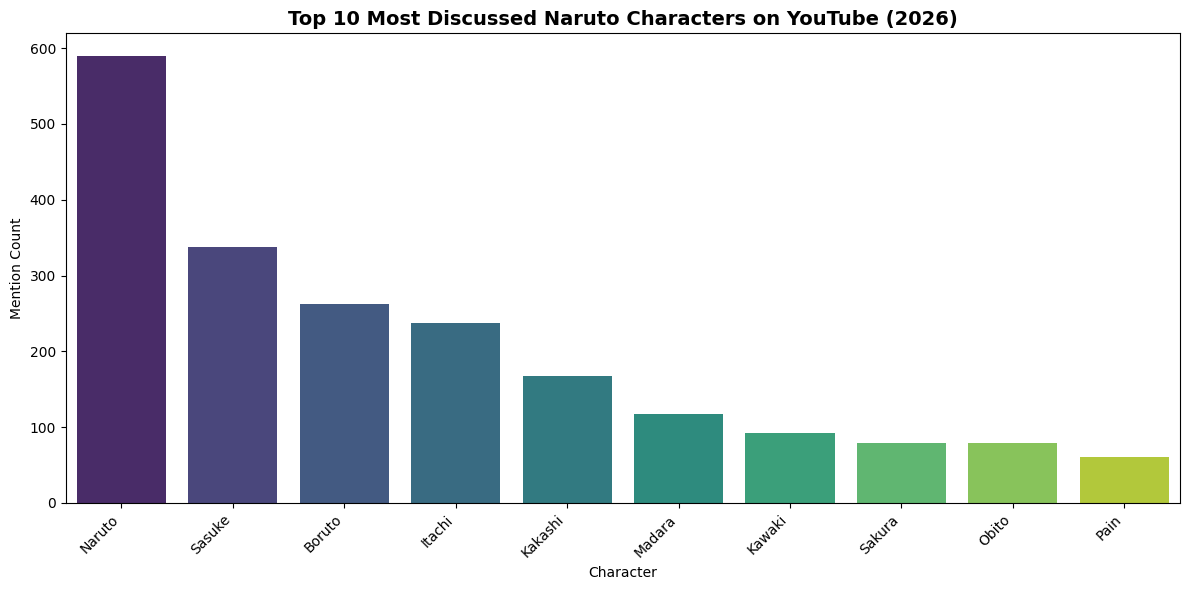

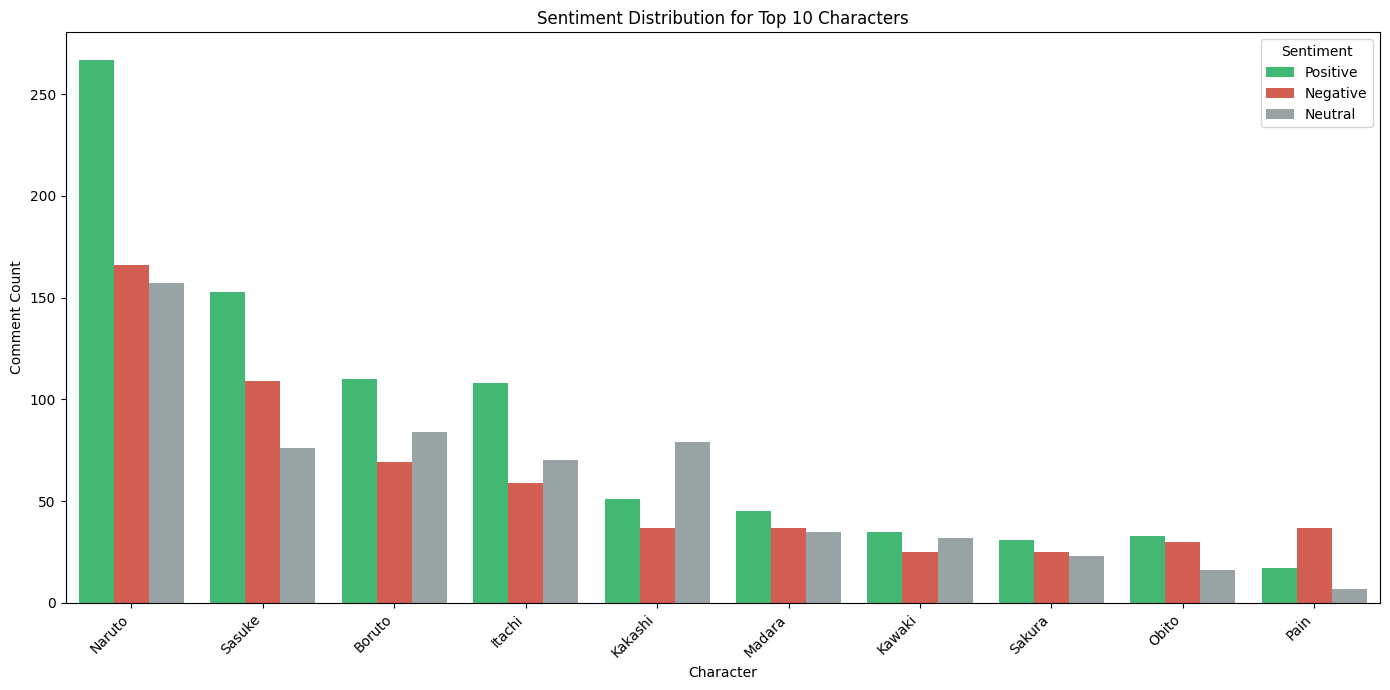

✅ Visualizations generated successfully!


In [41]:
# ========================== CELL 7: VISUALIZATIONS ==========================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=final_df, x="Character", y="Mentions", palette="viridis")
plt.title("Top 10 Most Discussed Naruto Characters on YouTube (2026)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mention Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
melted = final_df.melt(id_vars="Character", value_vars=["Positive", "Negative", "Neutral"])
sns.barplot(data=melted, x="Character", y="value", hue="variable",
            palette={"Positive": "#2ecc71", "Negative": "#e74c3c", "Neutral": "#95a5a6"})
plt.title("Sentiment Distribution for Top 10 Characters")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Comment Count")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

print("✅ Visualizations generated successfully!")

CELL 8: Save Results & Summary

In [42]:
# ========================== CELL 8: SAVE RESULTS ==========================
final_df.to_csv("Naruto_Top10_Sentiment_Analysis_Final.csv", index=False)
comments_df.to_csv("Raw_Collected_Comments.csv", index=False)

print("\n" + "="*70)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)
print(f"Most Discussed Character : {final_df.iloc[0]['Character']}")
print(f"Overall Sentiment        : {final_df.iloc[0]['Overall']}")
print(f"Total Comments Analyzed  : {len(comments_df)}")
print("\n📁 Files saved. Download them from the left sidebar (Files tab).")


🎉 PROJECT COMPLETED SUCCESSFULLY!
Most Discussed Character : Naruto
Overall Sentiment        : Positive
Total Comments Analyzed  : 3309

📁 Files saved. Download them from the left sidebar (Files tab).


Print the Top 10 Table and Final Sentiment Table

In [43]:
# ========================== CELL 9: SHOW FINAL TABLES ==========================
print("\n" + "="*70)
print("TOP 10 MOST FAMOUS CHARACTERS TABLE")
print("="*70)
display(top10_df)

print("\n" + "="*70)
print("FINAL SENTIMENT ANALYSIS TABLE")
print("="*70)
display(final_df)

# Save neat copies
top10_df.to_csv("Top10_Characters_Table.csv", index=False)
final_df.to_csv("Final_Sentiment_Table.csv", index=False)

print("\n✅ Tables saved as:")
print("   • Top10_Characters_Table.csv")
print("   • Final_Sentiment_Table.csv")


TOP 10 MOST FAMOUS CHARACTERS TABLE


,Character,Mentions
0,Naruto,590
1,Sasuke,338
2,Boruto,263
3,Itachi,237
4,Kakashi,167
5,Madara,117
6,Kawaki,92
7,Sakura,79
8,Obito,79
9,Pain,61



FINAL SENTIMENT ANALYSIS TABLE


,Character,Mentions,Positive,Negative,Neutral,Positive_%,Negative_%,Avg_Sentiment,Overall
0,Naruto,590,267,166,157,45.3,28.1,0.121,Positive
1,Sasuke,338,153,109,76,45.3,32.2,0.079,Positive
2,Boruto,263,110,69,84,41.8,26.2,0.105,Positive
3,Itachi,237,108,59,70,45.6,24.9,0.115,Positive
4,Kakashi,167,51,37,79,30.5,22.2,0.066,Positive
5,Madara,117,45,37,35,38.5,31.6,0.023,Neutral/Mixed
6,Kawaki,92,35,25,32,38.0,27.2,0.054,Positive
7,Sakura,79,31,25,23,39.2,31.6,0.060,Positive
8,Obito,79,33,30,16,41.8,38.0,-0.004,Neutral/Mixed
9,Pain,61,17,37,7,27.9,60.7,-0.176,Negative



✅ Tables saved as:
   • Top10_Characters_Table.csv
   • Final_Sentiment_Table.csv


Generate the Final Report Automatically from Your Results

In [44]:
# ========================== CELL 10: AUTO-GENERATE FINAL REPORT ==========================
top_character = final_df.iloc[0]["Character"]
top_mentions = int(final_df.iloc[0]["Mentions"])
top_sentiment = final_df.iloc[0]["Overall"]

most_positive_char = final_df.sort_values("Avg_Sentiment", ascending=False).iloc[0]["Character"]
most_positive_score = final_df.sort_values("Avg_Sentiment", ascending=False).iloc[0]["Avg_Sentiment"]

most_negative_char = final_df.sort_values("Avg_Sentiment", ascending=True).iloc[0]["Character"]
most_negative_score = final_df.sort_values("Avg_Sentiment", ascending=True).iloc[0]["Avg_Sentiment"]

total_comments = len(comments_df)
total_videos = len(videos_df)

report_text = f"""
FINAL RESEARCH REPORT

Title:
Sentiment Analysis of the 10 Most Discussed Characters in the Naruto Franchise:
A YouTube-Based Study Across Naruto, Naruto Shippuden, and Boruto

1. Introduction
The Naruto franchise, including Naruto, Naruto Shippuden, and Boruto: Naruto Next Generations,
has one of the largest and most active anime fan communities in the world. Fans regularly express
their opinions on characters through YouTube comments, reviews, reactions, rankings, and discussion videos.
This study uses sentiment analysis to identify the 10 most discussed characters in the franchise and
analyze audience sentiment toward them based on YouTube comments.

2. Objectives
The objectives of this research are:
1. To identify the top 10 most discussed Naruto franchise characters on YouTube.
2. To classify audience sentiment toward these characters as positive, negative, or neutral.
3. To compare character popularity and sentiment using comment-based text analysis.

3. Methodology
This study used the YouTube Data API v3 to collect comments from Naruto-related YouTube videos.
Videos were selected using keywords related to Naruto, Naruto Shippuden, and Boruto.
After collecting the comments, the text was cleaned by removing URLs, special characters, and extra spaces.
Character mentions were counted using name matching and aliases.
The top 10 characters were selected based on mention frequency.
Sentiment analysis was then performed using the VADER sentiment analysis tool, which classified comments
as positive, negative, or neutral based on compound sentiment scores.

4. Data Summary
Total videos analyzed: {total_videos}
Total comments analyzed: {total_comments}

5. Top 10 Most Discussed Characters
{top10_df.to_string(index=False)}

6. Final Sentiment Analysis Results
{final_df.to_string(index=False)}

7. Discussion
The results show that {top_character} is the most discussed character in the dataset, with {top_mentions} mentions.
This indicates that {top_character} remains highly relevant in fan discussions across the Naruto franchise.

Based on the sentiment analysis results, the overall sentiment toward {top_character} is {top_sentiment}.
This suggests that audience discussions around this character are largely shaped by strong emotional engagement,
character development, and memorable story impact.

The character with the highest average sentiment score is {most_positive_char}, with an average sentiment score of {most_positive_score}.
This means that this character receives the most favorable emotional response from YouTube audiences.

The character with the lowest average sentiment score is {most_negative_char}, with an average sentiment score of {most_negative_score}.
This may indicate mixed reception, controversial writing decisions, or divided fan opinions.

In general, the findings suggest that older legacy characters from Naruto and Naruto Shippuden tend to dominate
fan discussions more strongly than newer Boruto-era characters. This may be due to nostalgia, deeper emotional arcs,
and stronger audience attachment built over time.

8. Conclusion
This study successfully identified the top 10 most discussed Naruto franchise characters using YouTube comments
and analyzed the sentiment associated with each one. The findings show that character popularity can be effectively
measured using mention frequency, while fan perception can be evaluated through sentiment analysis.
Overall, the study demonstrates that YouTube comments are a valuable source of audience opinion and can be used
to understand character popularity and reception in long-running anime franchises.

9. Limitations
This study has several limitations:
1. The analysis is limited to YouTube comments only and does not include Twitter, Reddit, or other platforms.
2. Some comments may contain sarcasm, slang, or context that VADER may not fully understand.
3. Character name matching may miss rare nicknames or indirect references.
4. The number of videos and comments collected depends on API limits and selected search queries.

10. Recommendations
For future research, it is recommended to:
1. Include multiple social media platforms for broader audience coverage.
2. Use more advanced NLP models such as BERT for improved sentiment detection.
3. Compare sentiment across Naruto, Shippuden, and Boruto separately.
4. Analyze sentiment changes over time using publication year or arc-based grouping.

End of Report
"""

print(report_text)

with open("Final_Research_Report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print("\n✅ Final report saved as: Final_Research_Report.txt")


FINAL RESEARCH REPORT

Title:
Sentiment Analysis of the 10 Most Discussed Characters in the Naruto Franchise:
A YouTube-Based Study Across Naruto, Naruto Shippuden, and Boruto

1. Introduction
The Naruto franchise, including Naruto, Naruto Shippuden, and Boruto: Naruto Next Generations,
has one of the largest and most active anime fan communities in the world. Fans regularly express
their opinions on characters through YouTube comments, reviews, reactions, rankings, and discussion videos.
This study uses sentiment analysis to identify the 10 most discussed characters in the franchise and
analyze audience sentiment toward them based on YouTube comments.

2. Objectives
The objectives of this research are:
1. To identify the top 10 most discussed Naruto franchise characters on YouTube.
2. To classify audience sentiment toward these characters as positive, negative, or neutral.
3. To compare character popularity and sentiment using comment-based text analysis.

3. Methodology
This study u